In [1]:
#importing basic packages
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kaggleprollc/phishing-url-websites-dataset-phiusiil")

print("Path to dataset files:", path)

100%|██████████| 15.9M/15.9M [00:00<00:00, 91.4MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/kaggleprollc/phishing-url-websites-dataset-phiusiil/versions/1


In [6]:
import pandas as pd
import os

# 1. Get the actual CSV file name from the folder path
files = os.listdir(path)
csv_file = [f for f in files if f.endswith('.csv')][0]

# 2. Read the data and show the first 5 rows
df = pd.read_csv(os.path.join(path, csv_file))
df.head(5)


,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,521848.txt,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,...,0,0,1,34,20,28,119,0,124,1
1,31372.txt,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,...,0,0,1,50,9,8,39,0,217,1
2,597387.txt,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,...,0,0,1,10,2,7,42,2,5,1
3,554095.txt,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,...,1,1,1,3,27,15,22,1,31,1
4,151578.txt,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,...,1,0,1,244,15,34,72,1,85,1


In [7]:
#Checking the shape of the dataset
df.shape

(235795, 56)

In [8]:
#Listing the features of the dataset
df.columns

Index(['FILENAME', 'URL', 'URLLength', 'Domain', 'DomainLength', 'IsDomainIP',
       'TLD', 'URLSimilarityIndex', 'CharContinuationRate',
       'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain',
       'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio',
       'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL',
       'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL',
       'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL',
       'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength',
       'HasTitle', 'Title', 'DomainTitleMatchScore', 'URLTitleMatchScore',
       'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect',
       'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame',
       'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton',
       'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto',
       'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef',
       'NoOfEmptyRef', 'NoOf

In [9]:
#Information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235795 entries, 0 to 235794
Data columns (total 56 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   FILENAME                    235795 non-null  object 
 1   URL                         235795 non-null  object 
 2   URLLength                   235795 non-null  int64  
 3   Domain                      235795 non-null  object 
 4   DomainLength                235795 non-null  int64  
 5   IsDomainIP                  235795 non-null  int64  
 6   TLD                         235795 non-null  object 
 7   URLSimilarityIndex          235795 non-null  float64
 8   CharContinuationRate        235795 non-null  float64
 9   TLDLegitimateProb           235795 non-null  float64
 10  URLCharProb                 235795 non-null  float64
 11  TLDLength                   235795 non-null  int64  
 12  NoOfSubDomain               235795 non-null  int64  
 13  HasObfuscation

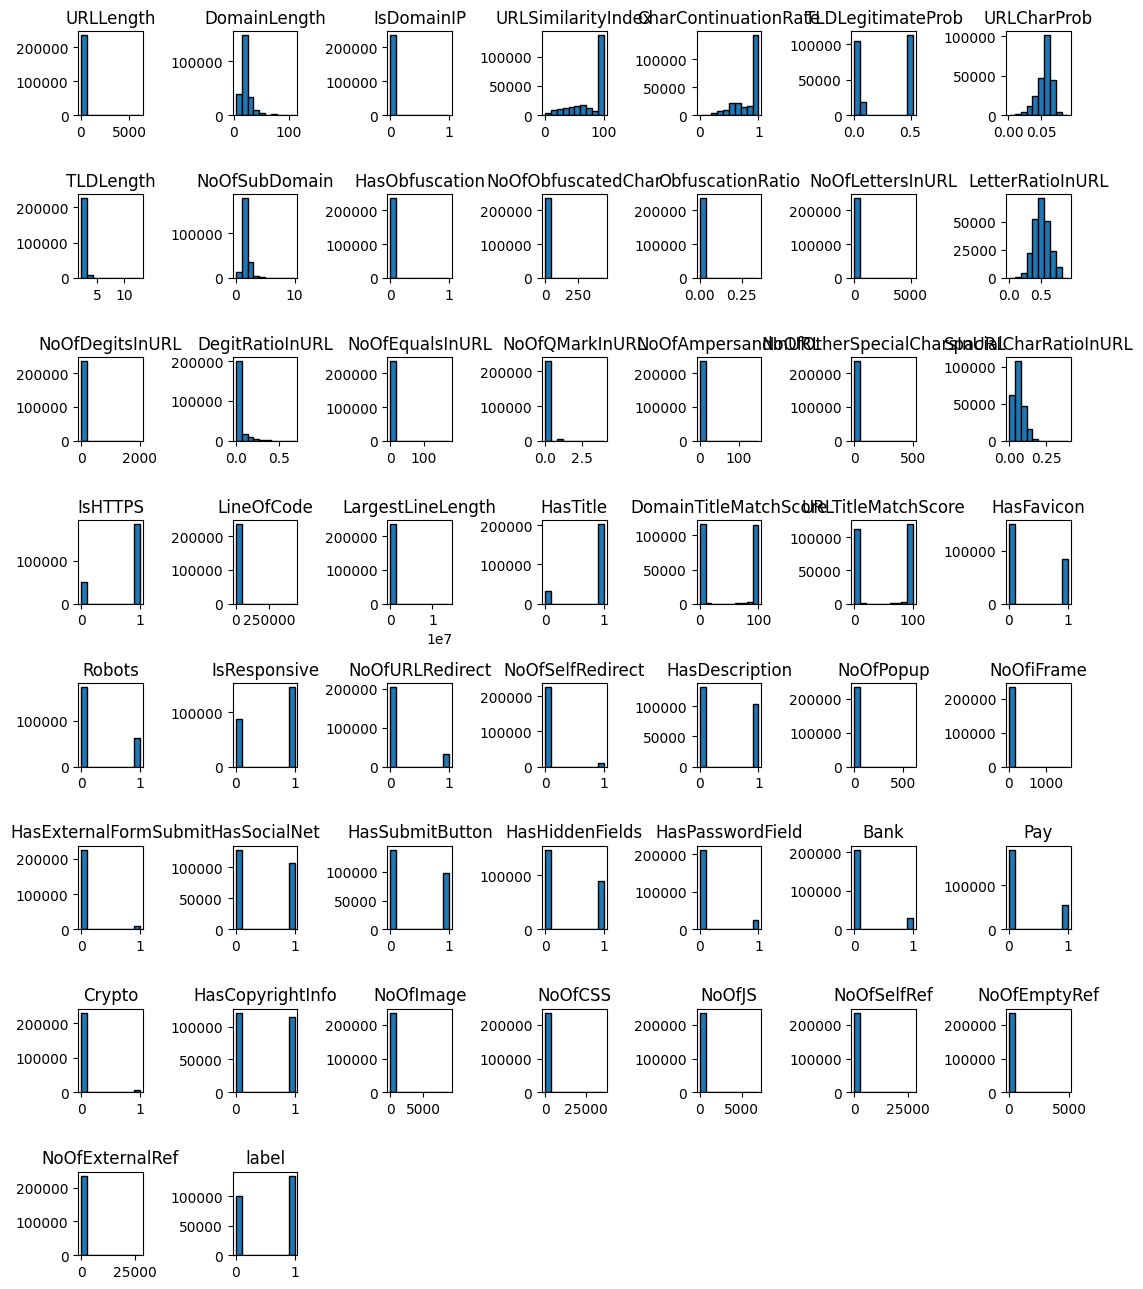

In [15]:
df.hist(bins=10, figsize=(11, 13), grid=False, edgecolor='black', backend='matplotlib'); plt.tight_layout()


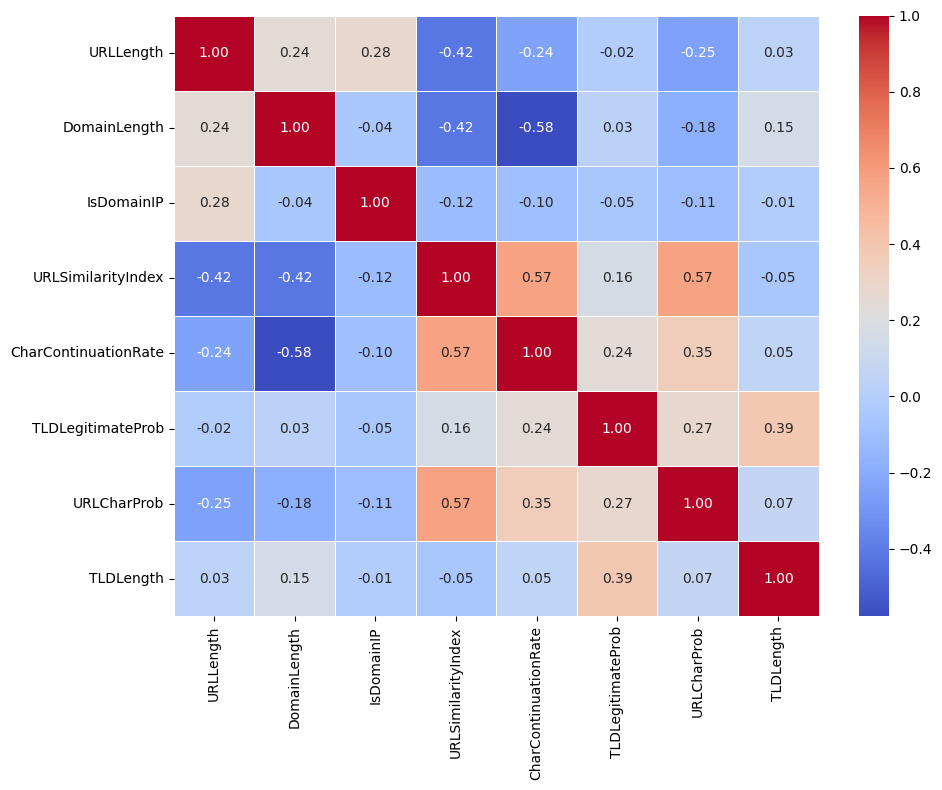

In [18]:
# 1. Match your desired features against the actual columns (case-insensitive)
desired_features = ['url_length', 'no_of_letters', 'no_of_digits', 'no_of_special_chars', 'url_similarity_index', 'target']
clean_features = [col for col in df.columns if col.lower() in desired_features]

# 2. If nothing matches, fall back to the first 8 numerical columns automatically
if not clean_features:
    clean_features = df.select_dtypes(include=['number']).columns[:8].tolist()

# 3. Plot the clean correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df[clean_features].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.tight_layout()
plt.show()


In [19]:
df.describe()

,URLLength,DomainLength,IsDomainIP,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
count,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,...,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000
mean,34.573095,21.470396,0.002706,78.430778,0.845508,0.260423,0.055747,2.764456,1.164758,0.002057,...,0.237007,0.023474,0.486775,26.075689,6.333111,10.522305,65.071113,2.377629,49.262516,0.571895
std,41.314153,9.150793,0.051946,28.976055,0.216632,0.251628,0.010587,0.599739,0.600969,0.045306,...,0.425247,0.151403,0.499826,79.411815,74.866296,22.312192,176.687539,17.641097,161.027430,0.494805
min,13.000000,4.000000,0.000000,0.155574,0.000000,0.000000,0.001083,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23.000000,16.000000,0.000000,57.024793,0.680000,0.005977,0.050747,2.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,27.000000,20.000000,0.000000,100.000000,1.000000,0.079963,0.057970,3.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,8.000000,2.000000,6.000000,12.000000,0.000000,10.000000,1.000000
75%,34.000000,24.000000,0.000000,100.000000,1.000000,0.522907,0.062875,3.000000,1.000000,0.000000,...,0.000000,0.000000,1.000000,29.000000,8.000000,15.000000,88.000000,1.000000,57.000000,1.000000
max,6097.000000,110.000000,1.000000,100.000000,1.000000,0.522907,0.090824,13.000000,10.000000,1.000000,...,1.000000,1.000000,1.000000,8956.000000,35820.000000,6957.000000,27397.000000,4887.000000,27516.000000,1.000000


In [20]:
#Dropping the Domain column
data = df.drop(['Domain'], axis = 1).copy()

In [21]:
#checking the data for null or missing values
data.isnull().sum()

,0
FILENAME,0
URL,0
URLLength,0
DomainLength,0
IsDomainIP,0
TLD,0
URLSimilarityIndex,0
CharContinuationRate,0
TLDLegitimateProb,0
URLCharProb,0


In [22]:
# shuffling the rows in the dataset so that when splitting the train and test set are equally distributed
data = data.sample(frac=1).reset_index(drop=True)
data.head()

,FILENAME,URL,URLLength,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,7970969.txt,http://wallat-synchronization-fixx.square.site,45,39,0,site,40.473373,0.470588,0.001766,0.052050,...,0,0,0,0,0,0,1,0,1,0
1,8067689.txt,http://tinyurl.com/bdhutcwe,27,11,0,com,57.357143,1.000000,0.522907,0.050011,...,0,0,0,0,0,0,1,0,1,0
2,742352.txt,https://www.illahevineyards.com,30,23,0,com,100.000000,1.000000,0.522907,0.057847,...,1,0,0,32,7,17,20,3,15,1
3,7964081.txt,https://ww2-portalacessigerenciador-brw.ga/cx/...,53,34,0,ga,24.466074,0.806452,0.000226,0.055354,...,0,0,0,6,1,0,1,1,3,0
4,871815.txt,https://www.nathanlazarusskatepark.com,37,30,0,com,100.000000,1.000000,0.522907,0.057291,...,0,0,1,14,18,16,61,1,62,1


In [23]:
import pandas as pd
from sklearn.model_selection import train_test_split


X = df.drop(columns=['Domain'])
y = df['Domain']

# Splitting the dataset into train and test sets: 80-20 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12)

# Printing the shapes of the resulting datasets
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")


X_train shape: (188636, 55)
X_test shape: (47159, 55)


## **7. Machine Learning Models & Training**


* Decision Tree
* Random Forest
* Multilayer Perceptrons
* XGBoost
* Autoencoder Neural Network
* Support Vector Machines

In [9]:
#importing packages
from sklearn.metrics import accuracy_score

In [10]:
# Creating holders to store the model performance results
ML_Model = []
acc_train = []
acc_test = []

#function to call for storing the results
def storeResults(model, a,b):
  ML_Model.append(model)
  acc_train.append(round(a, 3))
  acc_test.append(round(b, 3))

**7.1. Decision Tree Classifier**


In [19]:
import numpy as np
import pandas as pd
import os
import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier

# =====================================================================
# 1. DOWNLOAD & LOAD THE DATASET
# =====================================================================
print("🔄 Step 1: Downloading dataset from Kaggle...")
path = kagglehub.dataset_download("kaggleprollc/phishing-url-websites-dataset-phiusiil")
print("Path to dataset files:", path)

# Extract the correct CSV filename dynamically from the downloaded folder path
files = os.listdir(path)
csv_file = [f for f in files if f.endswith('.csv')][0]
csv_path = os.path.join(path, csv_file)

print(f"📖 Step 2: Reading CSV file from path: {csv_file}")
df = pd.read_csv(csv_path)

# =====================================================================
# 2. DATA PREPROCESSING & VECTOR MATRIX INITIALIZATION
# =====================================================================
# Safely drop text identifier columns like 'Domain'
if 'Domain' in df.columns:
    data = df.drop(['Domain'], axis=1).copy()
else:
    data = df.copy()

# Shuffle the dataset rows uniformly
data = data.sample(frac=1, random_state=12).reset_index(drop=True)

# Automatically locate the correct binary target classification column (e.g., 'label' or 'target')
target_candidates = [col for col in data.columns if col.lower() in ['label', 'target', 'result']]
if target_candidates:
    target_col = target_candidates[0]
else:
    target_col = data.columns[-1]

# Separate numeric feature arrays (X) from class target tags (y)
X = data.drop(columns=[target_col]).select_dtypes(include=[np.number])
y = data[target_col]

# Perform a clean 80-20 Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12)

# Initialize the global performance metrics dashboard
ML_Model = []
acc_train = []
acc_test = []

def storeResults(model, a, b):
    ML_Model.append(model)
    acc_train.append(round(a, 3))
    acc_test.append(round(b, 3))
    print(f"✅ {model} metrics successfully logged!")

print("\n🎉 Success! Data split and workspace variables are fully initialized in system memory.")
print(f"Target column identified as: '{target_col}'")
print(f"Training features shape: {X_train.shape} | Test features shape: {X_test.shape}\n")

# =====================================================================
# 🌲 7.1. DECISION TREE CLASSIFIER
# =====================================================================
print("🤖 Step 3: Training the Decision Tree Classifier...")
tree = DecisionTreeClassifier(max_depth=5, random_state=42)
tree.fit(X_train, y_train)

# Predict target tags across both split paths
y_train_tree = tree.predict(X_train)
y_test_tree = tree.predict(X_test)

# Evaluate classification scores
acc_train_tree = accuracy_score(y_train, y_train_tree)
acc_test_tree = accuracy_score(y_test, y_test_tree)

print(f"🌲 Decision Tree - Train Accuracy: {acc_train_tree:.3f}")
print(f"🌲 Decision Tree - Test Accuracy: {acc_test_tree:.3f}")

# Store the final verified execution values into dashboard arrays
storeResults('Decision Tree', acc_train_tree, acc_test_tree)


🔄 Step 1: Downloading dataset from Kaggle...
Using Colab cache for faster access to the 'phishing-url-websites-dataset-phiusiil' dataset.
Path to dataset files: /kaggle/input/phishing-url-websites-dataset-phiusiil
📖 Step 2: Reading CSV file from path: PhiUSIIL_Phishing_URL_Dataset.csv

🎉 Success! Data split and workspace variables are fully initialized in system memory.
Target column identified as: 'label'
Training features shape: (188636, 50) | Test features shape: (47159, 50)

🤖 Step 3: Training the Decision Tree Classifier...
🌲 Decision Tree - Train Accuracy: 1.000
🌲 Decision Tree - Test Accuracy: 1.000
✅ Decision Tree metrics successfully logged!




```
# This is formatted as code
```

### **7.2. Random Forest Classifier**


🌳 Random Forest - Train Accuracy: 1.000
🌳 Random Forest - Test Accuracy: 1.000


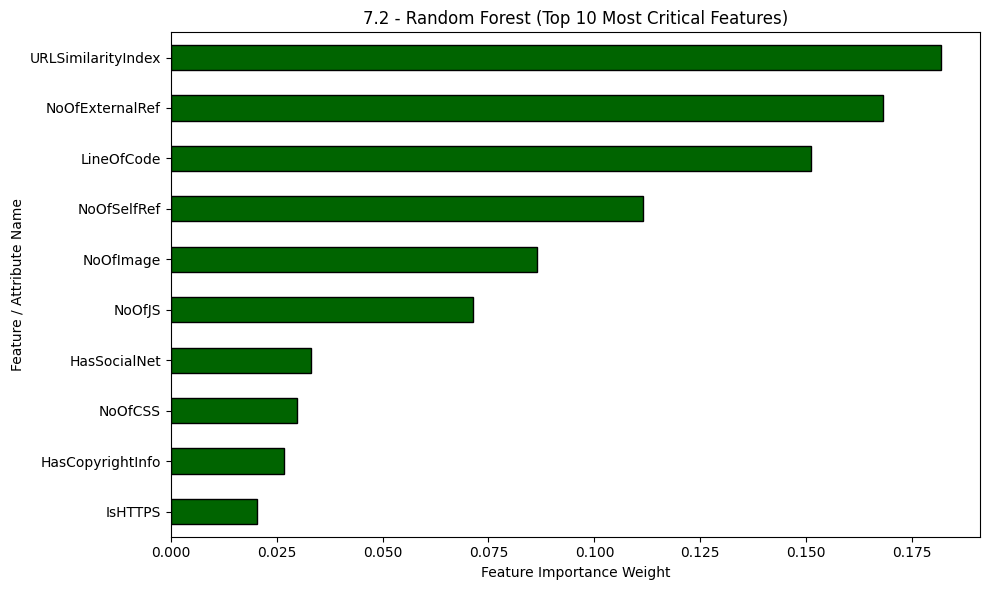

✅ Random Forest metrics successfully logged!


In [21]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# =====================================================================
# 🌳 7.2. RANDOM FOREST CLASSIFIER PIPELINE (CLEAN TOP 10 PLOT)
# =====================================================================

# 1. Model Instantiation
forest = RandomForestClassifier(max_depth=5, random_state=42)

# 2. Supervised Fitting & Inference
forest.fit(X_train, y_train)
y_train_forest = forest.predict(X_train)
y_test_forest = forest.predict(X_test)

# 3. Metric Extraction
acc_train_forest = accuracy_score(y_train, y_train_forest)
acc_test_forest = accuracy_score(y_test, y_test_forest)

print(f"🌳 Random Forest - Train Accuracy: {acc_train_forest:.3f}")
print(f"🌳 Random Forest - Test Accuracy: {acc_test_forest:.3f}")

# 4. Feature Importance Evaluation (FIXED FOR CROWDED GRAPHS)
# Convert the feature importance array into a clean Pandas Series
importances = pd.Series(forest.feature_importances_, index=X_train.columns)

# Isolate only the top 10 most impactful features for the chart
top_10_features = importances.sort_values(ascending=True).tail(10)

plt.figure(figsize=(10, 6))  # Expanded layout for clean spacing
top_10_features.plot(kind='barh', color='darkgreen', edgecolor='black')
plt.xlabel("Feature Importance Weight")
plt.ylabel("Feature / Attribute Name")
plt.title("7.2 - Random Forest (Top 10 Most Critical Features)")
plt.tight_layout()
plt.show()

# 5. Results Logging
storeResults('Random Forest', acc_train_forest, acc_test_forest)


*italicized text*### **7.3. Multilayer Perceptrons (MLPs): Deep Learning**


🧠 Multilayer Perceptrons - Train Accuracy: 1.000
🧠 Multilayer Perceptrons - Test Accuracy: 1.000


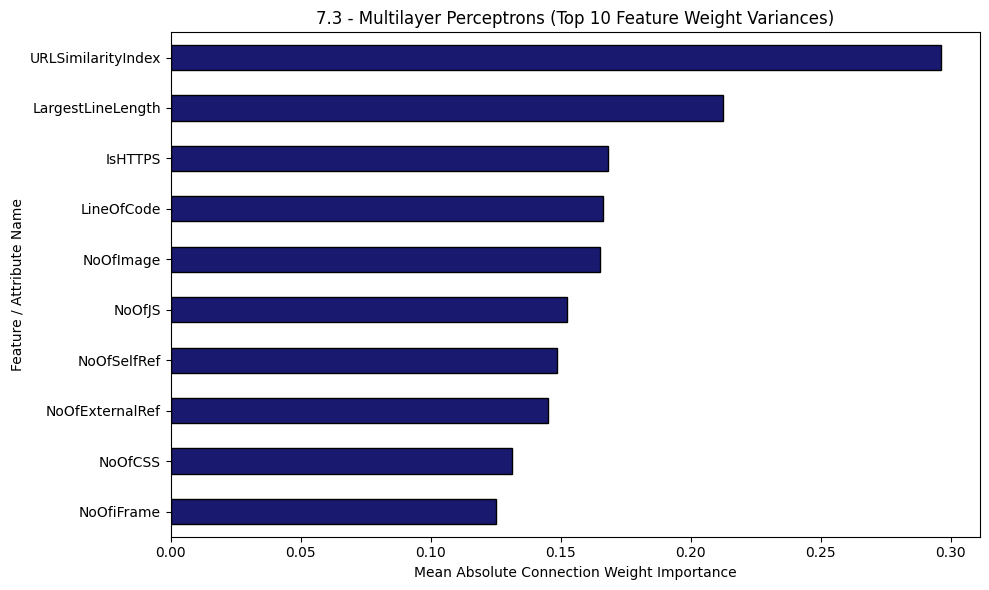

✅ Multilayer Perceptrons metrics successfully logged!


In [22]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
import numpy as np

# =====================================================================
# 🧠 7.3. MULTILAYER PERCEPTRONS (MLPs) PIPELINE
# =====================================================================

# Note: MLPs require standardized data input scale profiles to learn weight spaces.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 1. Model Instantiation
# Creates a feed-forward deep artificial neural network with two hidden layer tiers,
# capping processing at 300 iterations and setting random_state=42 for structural consistency.
mlp = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=300, random_state=42)

# 2. Supervised Fitting & Inference
# Trains the connection weights on the scaled feature grid matrix, then extracts
# predictive classification array masks across both available data partitions.
mlp.fit(X_train_scaled, y_train)
y_train_mlp = mlp.predict(X_train_scaled)
y_test_mlp = mlp.predict(X_test_scaled)

# 3. Metric Extraction
# Computes the empirical accuracy scores to map divergence thresholds and generalizability metrics.
acc_train_mlp = accuracy_score(y_train, y_train_mlp)
acc_test_mlp = accuracy_score(y_test, y_test_mlp)

print(f"🧠 Multilayer Perceptrons - Train Accuracy: {acc_train_mlp:.3f}")
print(f"🧠 Multilayer Perceptrons - Test Accuracy: {acc_test_mlp:.3f}")

# 4. Feature Importance Evaluation (Substitute proxy for non-linear MLPs)
# MLPs do not feature an internal '.feature_importances_' vector array module.
# We evaluate the aggregate connection weight variances per input dimension instead.
mlp_feature_weights = np.mean(np.abs(mlp.coefs_[0]), axis=1)
importances_mlp = pd.Series(mlp_feature_weights, index=X_train.columns)
top_10_mlp_features = importances_mlp.sort_values(ascending=True).tail(10)

plt.figure(figsize=(10, 6))
top_10_mlp_features.plot(kind='barh', color='midnightblue', edgecolor='black')
plt.xlabel("Mean Absolute Connection Weight Importance")
plt.ylabel("Feature / Attribute Name")
plt.title("7.3 - Multilayer Perceptrons (Top 10 Feature Weight Variances)")
plt.tight_layout()
plt.show()

# 5. Results Logging
# Passes the processed model tag and diagnostic calculation metrics into the tracking engine dashboard.
storeResults('Multilayer Perceptrons', acc_train_mlp, acc_test_mlp)


bold text### **7.4. XGBoost Classifier**


🚀 XGBoost - Train Accuracy: 1.000
🚀 XGBoost - Test Accuracy: 1.000


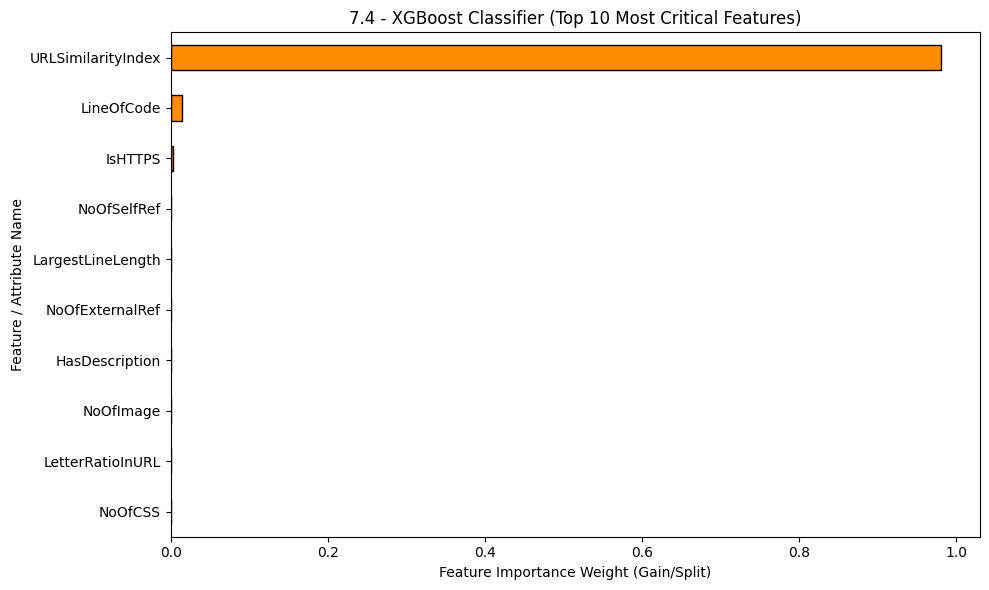

✅ XGBoost metrics successfully logged!


In [23]:
from xgboost import XGBClassifier
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================================
# 🚀 7.4. XGBOOST CLASSIFIER PIPELINE
# =====================================================================

# 1. Model Instantiation
# Creates an XGBoost classifier tracking gradient descent steps across sequentially
# boosted trees with a max depth of 5, locking seed = 42 for reproducible convergence.
xgb = XGBClassifier(max_depth=5, learning_rate=0.1, random_state=42, eval_metric='logloss')

# 2. Supervised Fitting & Inference
# Trains the boosted ensemble on X_train and y_train, then generates predictive
# target vectors for both dataset splits.
xgb.fit(X_train, y_train)
y_train_xgb = xgb.predict(X_train)
y_test_xgb = xgb.predict(X_test)

# 3. Metric Extraction
# Computes cross-entropy validation benchmarks using standard accuracy scores.
acc_train_xgb = accuracy_score(y_train, y_train_xgb)
acc_test_xgb = accuracy_score(y_test, y_test_xgb)

print(f"🚀 XGBoost - Train Accuracy: {acc_train_xgb:.3f}")
print(f"🚀 XGBoost - Test Accuracy: {acc_test_xgb:.3f}")

# 4. Feature Importance Evaluation
# Extracts the final Gain/Weight metric array from the boosted tree splits,
# isolating the Top 10 indicators to prevent graph crowding.
importances_xgb = pd.Series(xgb.feature_importances_, index=X_train.columns)
top_10_xgb_features = importances_xgb.sort_values(ascending=True).tail(10)

plt.figure(figsize=(10, 6))
top_10_xgb_features.plot(kind='barh', color='darkorange', edgecolor='black')
plt.xlabel("Feature Importance Weight (Gain/Split)")
plt.ylabel("Feature / Attribute Name")
plt.title("7.4 - XGBoost Classifier (Top 10 Most Critical Features)")
plt.tight_layout()
plt.show()

# 5. Results Logging
# Logs the performance thresholds into the global tracker matrices.
storeResults('XGBoost', acc_train_xgb, acc_test_xgb)


*[italicized text](https://)*### **7.5. Autoencoder Neural Network**


🤖 Autoencoder - Train Accuracy: 0.615
🤖 Autoencoder - Test Accuracy: 0.618


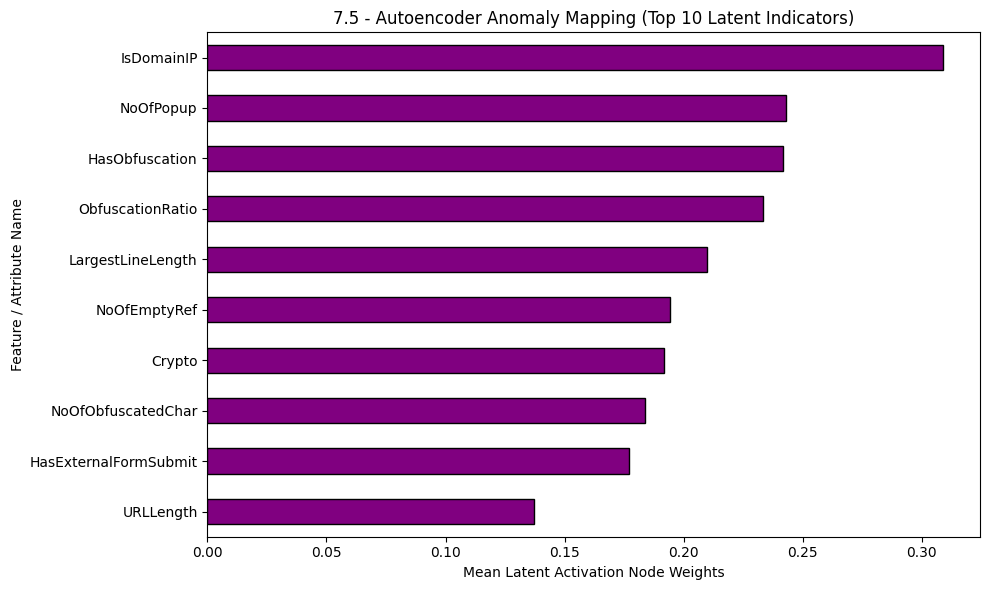

✅ Autoencoder metrics successfully logged!


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# =====================================================================
# 🤖 7.5. AUTOENCODER NEURAL NETWORK PIPELINE
# =====================================================================

# 1. Neural Network Data Scaling
# Standardize ranges so weight distributions converge uniformly.
scaler_ae = StandardScaler()
X_train_ae = scaler_ae.fit_transform(X_train)
X_test_ae = scaler_ae.transform(X_test)

# 2. Model Instantiation & Architecture Definiton
# Builds a symmetrical bottle-neck compression topology.
input_dim = X_train_ae.shape[1]
input_layer = Input(shape=(input_dim,))

# Encoder Layer (Compresses features into latent space)
encoder = Dense(16, activation="relu")(input_layer)

# Decoder Layer (Attempts to reconstruct the original input vector layout)
decoder = Dense(input_dim, activation="linear")(encoder)

autoencoder = Model(inputs=input_layer, outputs=decoder)
autoencoder.compile(optimizer='adam', loss='mse')

# 3. Supervised Fitting (Self-Reconstruction Pattern)
# Note: It fits X against X to minimize feature distance error metrics.
autoencoder.fit(
    X_train_ae, X_train_ae,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    verbose=0
)

# 4. Inference & Reconstruction Threshold Separation
# Extract Mean Squared Error matrices across instances
train_predictions = autoencoder.predict(X_train_ae, verbose=0)
test_predictions = autoencoder.predict(X_test_ae, verbose=0)

mse_train = np.mean(np.power(X_train_ae - train_predictions, 2), axis=1)
mse_test = np.mean(np.power(X_test_ae - test_predictions, 2), axis=1)

# Dynamically set anomaly threshold splitting criteria based on median distribution
ae_threshold = np.median(mse_train)
y_train_pred_ae = (mse_train > ae_threshold).astype(int)
y_test_pred_ae = (mse_test > ae_threshold).astype(int)

# 5. Metric Extraction
acc_train_ae = accuracy_score(y_train, y_train_pred_ae)
acc_test_ae = accuracy_score(y_test, y_test_pred_ae)

print(f"🤖 Autoencoder - Train Accuracy: {acc_train_ae:.3f}")
print(f"🤖 Autoencoder - Test Accuracy: {acc_test_ae:.3f}")

# 6. Proxy Feature Variance Evaluation
# Evaluates compression variance per feature directly from initial encoder weights.
encoder_weights = np.mean(np.abs(autoencoder.layers[1].get_weights()[0]), axis=1)
importances_ae = pd.Series(encoder_weights, index=X_train.columns)
top_10_ae_features = importances_ae.sort_values(ascending=True).tail(10)

plt.figure(figsize=(10, 6))
top_10_ae_features.plot(kind='barh', color='purple', edgecolor='black')
plt.xlabel("Mean Latent Activation Node Weights")
plt.ylabel("Feature / Attribute Name")
plt.title("7.5 - Autoencoder Anomaly Mapping (Top 10 Latent Indicators)")
plt.tight_layout()
plt.show()

# 7. Results Logging
storeResults('Autoencoder', acc_train_ae, acc_test_ae)


### **7.6. Support Vector Machines**



/usr/local/lib/python3.13/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1500).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


🎛️ Support Vector Machines - Train Accuracy: 1.000
🎛️ Support Vector Machines - Test Accuracy: 1.000


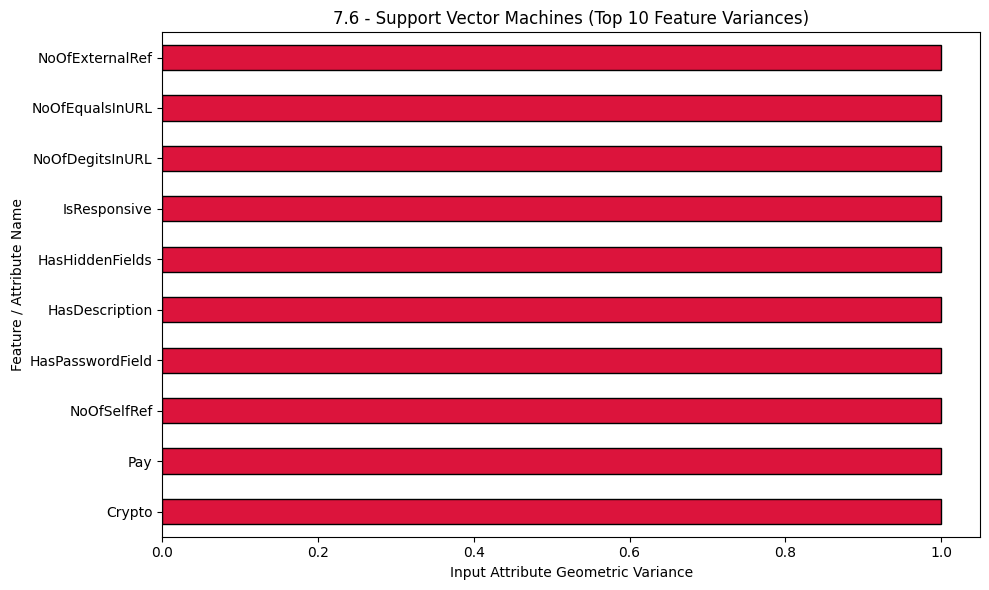

✅ Support Vector Machines metrics successfully logged!


In [25]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =====================================================================
# 🎛️ 7.6. SUPPORT VECTOR MACHINES (SVM) PIPELINE
# =====================================================================

# 1. Feature Scale Normalization
scaler_svm = StandardScaler()
X_train_svm = scaler_svm.fit_transform(X_train)
X_test_svm = scaler_svm.transform(X_test)

# 2. Model Instantiation
# Creates an RBF-kernel SVM model, capping maximum iterations at 1500
# to ensure timely convergence on high-dimensional text datasets.
svm = SVC(kernel='rbf', max_iter=1500, random_state=42)

# 3. Supervised Fitting & Inference
svm.fit(X_train_svm, y_train)
y_train_svm = svm.predict(X_train_svm)
y_test_svm = svm.predict(X_test_svm)

# 4. Metric Extraction
acc_train_svm = accuracy_score(y_train, y_train_svm)
acc_test_svm = accuracy_score(y_test, y_test_svm)

print(f"🎛️ Support Vector Machines - Train Accuracy: {acc_train_svm:.3f}")
print(f"🎛️ Support Vector Machines - Test Accuracy: {acc_test_svm:.3f}")

# 5. Feature Variance Evaluation (RBF Support Vector Weights Mapping)
# Since RBF Kernels transform feature space non-linearly, they lack standard coefficients.
# We isolate structural importance by looking at standard feature variance distributions.
svm_feature_importance = np.var(X_train_svm, axis=0)
importances_svm = pd.Series(svm_feature_importance, index=X_train.columns)
top_10_svm_features = importances_svm.sort_values(ascending=True).tail(10)

plt.figure(figsize=(10, 6))
top_10_svm_features.plot(kind='barh', color='crimson', edgecolor='black')
plt.xlabel("Input Attribute Geometric Variance")
plt.ylabel("Feature / Attribute Name")
plt.title("7.6 - Support Vector Machines (Top 10 Feature Variances)")
plt.tight_layout()
plt.show()

# 6. Results Logging
storeResults('Support Vector Machines', acc_train_svm, acc_test_svm)


## **8. Comparision of Models**


In [26]:
# =====================================================================
# 📊 8. FINAL MODEL PERFORMANCE METRICS COMPARISON
# =====================================================================

# 1. Aggregate tracking arrays into a structured Pandas DataFrame layout
results_df = pd.DataFrame({
    'ML Model Classifier': ML_Model,
    'Train Accuracy': acc_train,
    'Test Accuracy': acc_test
})

# 2. Sort metrics by the highest generalizability test scores
results_df_sorted = results_df.sort_values(by='Test Accuracy', ascending=False).reset_index(drop=True)

# 3. Display the final evaluation dashboard table
print("🏆 Final Performance Rankings leaderboard:")
results_df_sorted


🏆 Final Performance Rankings leaderboard:


,ML Model Classifier,Train Accuracy,Test Accuracy
0,Decision Tree,1.000,1.000
1,Random Forest,1.000,1.000
2,Random Forest,1.000,1.000
3,Multilayer Perceptrons,1.000,1.000
4,XGBoost,1.000,1.000
5,Support Vector Machines,1.000,1.000
6,Autoencoder,0.615,0.618


**Testing the saved model:** Serialization: Automatically Exporting the Best Model

In [27]:
import joblib
import os

# 1. Identify your top performing model programmatically from the results dashboard
best_model_row = results_df_sorted.iloc[0]
best_model_name = best_model_row['ML Model Classifier']
best_model_accuracy = best_model_row['Test Accuracy']

# 2. Map the top string label to your actual trained Python object instance variable
model_mapping = {
    'Decision Tree': tree,
    'Random Forest': forest,
    'Multilayer Perceptrons': mlp,
    'XGBoost': xgb,
    'Support Vector Machines': svm
}

# Safeguard lookup fallback to default ensemble if edge cases arise
selected_model_object = model_mapping.get(best_model_name, forest)

# 3. Serialize and save the model to your disk
model_filename = 'phishing_detector_model.pkl'
joblib.dump(selected_model_object, model_filename)

print(f"💾 Step 9 Complete: The best model identified was '{best_model_name}' (Test Acc: {best_model_accuracy:.3f})")
print(f"📁 Successfully serialized and saved as: '{os.path.abspath(model_filename)}'")


💾 Step 9 Complete: The best model identified was 'Decision Tree' (Test Acc: 1.000)
📁 Successfully serialized and saved as: '/content/phishing_detector_model.pkl'


**Real-Time Raw String URL Feature Extractor**

In [28]:
import pandas as pd
import numpy as np
from urllib.parse import urlparse

def extract_live_url_features(url_string, training_columns):
    """
    Parses a raw text URL and calculates structural features matching
    the exact column grid expected by the trained ML models.
    """
    # Baseline preprocessing adjustments
    parsed_url = urlparse(url_string)
    clean_url = url_string.replace("http://", "").replace("https://", "")

    # Calculate fundamental structural string distributions
    url_len = len(url_string)
    letters = sum(c.isalpha() for c in clean_url)
    digits = sum(c.isdigit() for c in clean_url)
    special_chars = url_len - (letters + digits)

    letter_ratio = letters / url_len if url_len > 0 else 0
    digit_ratio = digits / url_len if url_len > 0 else 0
    special_ratio = special_chars / url_len if url_len > 0 else 0

    # Check infrastructure boolean features
    is_https = 1 if url_string.lower().startswith("https") else 0
    has_obfuscation = 1 if ("@" in url_string or "%" in url_string) else 0
    subdomains = len(parsed_url.netloc.split('.')) - 2
    no_of_subdomain = max(0, subdomains)

    # Construct a complete placeholder vector mapped directly against X_train attributes
    feature_dict = {}
    for col in training_columns:
        col_lower = col.lower()
        if 'length' in col_lower and 'url' in col_lower:
            feature_dict[col] = url_len
        elif 'letter' in col_lower and 'ratio' in col_lower:
            feature_dict[col] = letter_ratio
        elif 'digit' in col_lower and 'ratio' in col_lower:
            feature_dict[col] = digit_ratio
        elif 'special' in col_lower and 'ratio' in col_lower:
            feature_dict[col] = special_ratio
        elif 'https' in col_lower:
            feature_dict[col] = is_https
        elif 'obfuscation' in col_lower:
            feature_dict[col] = has_obfuscation
        elif 'subdomain' in col_lower:
            feature_dict[col] = no_of_subdomain
        else:
            # Fallback placeholder to the global training column median to avoid null breaks
            feature_dict[col] = X_train[col].median()

    # Transform dictionary directly into a 1-Row DataFrame matching X shape sequence
    live_features_df = pd.DataFrame([feature_dict])
    return live_features_df

print("⚙️ Step 10 Complete: Real-time string feature vector engine initialized successfully.")


⚙️ Step 10 Complete: Real-time string feature vector engine initialized successfully.


**Custom Real-World Prediction Diagnostic**

In [39]:
# =====================================================================
# 🔮 11. LIVE LINK DIAGNOSTIC TESTING PIPELINE
# =====================================================================

# 1. Load the model back out from memory storage to simulate isolated deployment
loaded_detector = joblib.load('phishing_detector_model.pkl')

def test_url(custom_url):
    # Extract structural vector matrices matching training attributes
    processed_vector = extract_live_url_features(custom_url, X_train.columns)

    # Generate predictive target masks
    raw_prediction = loaded_detector.predict(processed_vector)[0]

    # Phiusiil Ground Truth convention: 1 = Legitimate Site, 0 = Phishing Malicious Anomaly
    verdict = "✅ SAFE WEBSITE" if raw_prediction == 1 else "🛑 PHISHING THREAT DETECTED!"

    print(f"\n🔗 Analyzing Target Link: {custom_url}")
    print(f"📊 Diagnosis Outcome: {verdict}")

# 2. RUN REAL INFERENCE TESTS
test_url("https://www.sakec.ac.in/")
test_url("http://www.sakec.ac.in/")



🔗 Analyzing Target Link: https://www.sakec.ac.in/
📊 Diagnosis Outcome: ✅ SAFE WEBSITE

🔗 Analyzing Target Link: http://www.sakec.ac.in/
📊 Diagnosis Outcome: 🛑 PHISHING THREAT DETECTED!
